In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1636_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1615_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1629_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1635_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/WISDM-dataset-description.pdf
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1607_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1624_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1639_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1637_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1603_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1644_accel_phone.csv
/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/data_1633_acce

In [59]:
import os

base_path = "/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/"

files = os.listdir(base_path)


In [60]:
import pandas as pd
import os

base_path = "/kaggle/input/datasets/ruhallahahmadian/wisdm-51/WISDM-51/"

all_data = []

for file in os.listdir(base_path):
    if file.endswith(".csv") and "accel_phone" in file:
        df_temp = pd.read_csv(os.path.join(base_path, file))
        all_data.append(df_temp)

df = pd.concat(all_data, ignore_index=True)
print("Shape:", df.shape)
print(df.head())

Shape: (4804403, 6)
   Subject-id Activity Label        Timestamp   X-accel    Y-accel   Z-accel
0        1636              A  504627630476589 -4.471436 -11.006256 -0.353561
1        1636              A  504627680830592 -5.207367 -12.732834 -1.629135
2        1636              A  504627731184596 -5.844177 -11.135010 -2.733383
3        1636              A  504627781538600 -7.345474  -7.403900 -1.969910
4        1636              A  504627831892604 -8.717712  -5.766296  0.025681


In [61]:

# Drop rows with missing values
df = df.dropna()

# Convert numeric columns properly
df["X-accel"] = pd.to_numeric(df["X-accel"], errors="coerce")
df["Y-accel"] = pd.to_numeric(df["Y-accel"], errors="coerce")
df["Z-accel"] = pd.to_numeric(df["Z-accel"], errors="coerce")

# Drop rows where conversion failed
df = df.dropna()

# Convert timestamp to numeric (if needed)
df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
df = df.dropna()

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df.head())

Cleaned shape: (4804403, 6)
   Subject-id Activity Label        Timestamp   X-accel    Y-accel   Z-accel
0        1636              A  504627630476589 -4.471436 -11.006256 -0.353561
1        1636              A  504627680830592 -5.207367 -12.732834 -1.629135
2        1636              A  504627731184596 -5.844177 -11.135010 -2.733383
3        1636              A  504627781538600 -7.345474  -7.403900 -1.969910
4        1636              A  504627831892604 -8.717712  -5.766296  0.025681


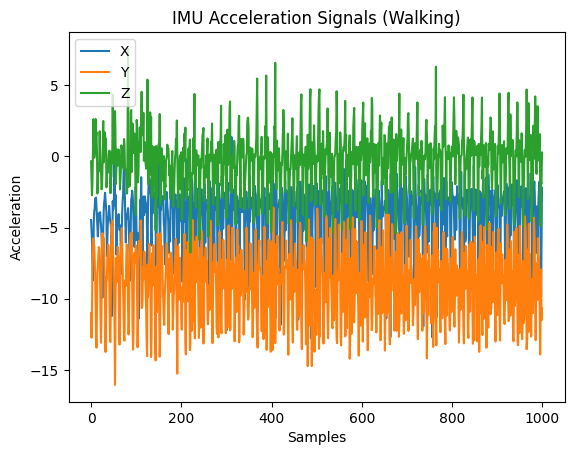

In [62]:
import matplotlib.pyplot as plt

# Filter one activity (e.g., walking)
walking_df = df[df["Activity Label"] == "A"]

# Take a small sample (important for visualization)
sample = walking_df.iloc[:1000]

# Plot acceleration signals
plt.figure()
plt.plot(sample["X-accel"], label="X")
plt.plot(sample["Y-accel"], label="Y")
plt.plot(sample["Z-accel"], label="Z")

plt.title("IMU Acceleration Signals (Walking)")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()
plt.show()

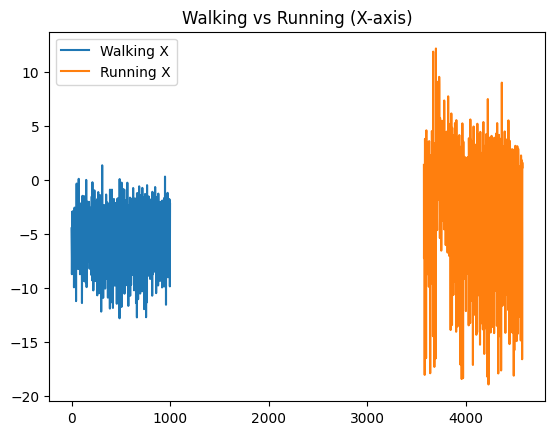

In [63]:
running_df = df[df["Activity Label"] == "B"]

sample_walk = walking_df.iloc[:1000]
sample_run = running_df.iloc[:1000]

plt.figure()
plt.plot(sample_walk["X-accel"], label="Walking X")
plt.plot(sample_run["X-accel"], label="Running X")

plt.title("Walking vs Running (X-axis)")
plt.legend()
plt.show()

/tmp/ipykernel_55/898572495.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample["x_filtered"] = filtfilt(b, a, sample["X-accel"])


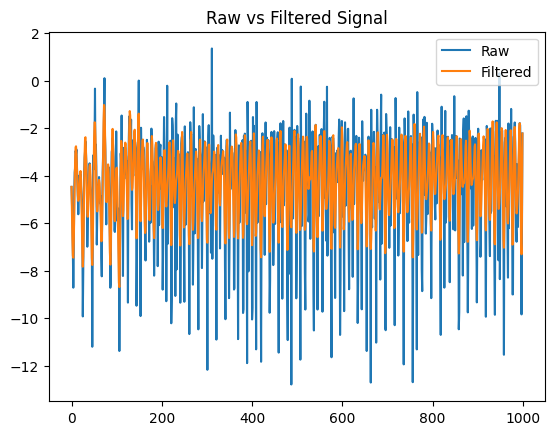

In [64]:
from scipy.signal import butter, filtfilt

# Sampling frequency (WISDM is ~20 Hz usually, but confirm if needed)
fs = 20  

# Nyquist frequency
nyq = 0.5 * fs  

# Cutoff frequency (keep gait, remove noise)
cutoff = 3  # Hz (walking/running typically < 3 Hz)

# Normalize cutoff
normal_cutoff = cutoff / nyq

# Create filter
b, a = butter(4, normal_cutoff, btype='low', analog=False)

# Apply filter to X axis
sample["x_filtered"] = filtfilt(b, a, sample["X-accel"])

# Plot comparison
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sample["X-accel"], label="Raw")
plt.plot(sample["x_filtered"], label="Filtered")

plt.title("Raw vs Filtered Signal")
plt.legend()
plt.show()

In [65]:
fs = 20  

# Nyquist frequency
nyq = 0.5 * fs  

# Cutoff frequency (keep gait, remove noise)
cutoff = 3  # Hz (walking/running typically < 3 Hz)

# Normalize cutoff
normal_cutoff = cutoff / nyq

# Create filter
b, a = butter(4, normal_cutoff, btype='low', analog=False)

df["x_f"] = filtfilt(b, a, df["X-accel"])
df["y_f"] = filtfilt(b, a, df["Y-accel"])
df["z_f"] = filtfilt(b, a, df["Z-accel"])


In [66]:

df["acc_mag"] = np.sqrt(
    df["x_f"]**2 +
    df["y_f"]**2 +
    df["z_f"]**2
)

In [67]:
window_size = 40   # 2 seconds
step_size = 20     # 50% overlap

segments = []

for i in range(0, len(df) - window_size, step_size):
    window = df["acc_mag"].iloc[i:i+window_size].values
    segments.append(window)

print("Number of segments:", len(segments))
print("Shape of one segment:", segments[0].shape)

Number of segments: 240219
Shape of one segment: (40,)


In [68]:
features = []

for segment in segments:
    feat = {
        "mean": np.mean(segment),
        "std": np.std(segment),
        "max": np.max(segment),
        "min": np.min(segment),
        "range": np.max(segment) - np.min(segment),
        "energy": np.sum(segment**2)
    }
    features.append(feat)

features_df = pd.DataFrame(features)

print(features_df.head())

        mean       std        max       min     range       energy
0  10.020507  1.761528  12.674648  7.406266  5.268382  4140.541577
1  10.128883  1.748469  13.033640  7.420457  5.613184  4226.056831
2  10.158431  1.695129  13.033640  7.461555  5.572085  4242.687604
3  10.040164  1.829723  12.920244  6.651299  6.268945  4166.110990
4   9.900413  2.018734  13.034872  6.651299  6.383572  4083.738643


In [69]:
from scipy.fft import fft

fft_features = []

for segment in segments:
    fft_vals = np.abs(fft(segment))
    
    feat = {
        "fft_mean": np.mean(fft_vals),
        "fft_max": np.max(fft_vals),
        "fft_energy": np.sum(fft_vals**2)
    }
    fft_features.append(feat)

fft_df = pd.DataFrame(fft_features)

# Combine
final_features = pd.concat([features_df, fft_df], axis=1)

print(final_features.head())

        mean       std        max       min     range       energy   fft_mean  \
0  10.020507  1.761528  12.674648  7.406266  5.268382  4140.541577  14.846483   
1  10.128883  1.748469  13.033640  7.420457  5.613184  4226.056831  14.423480   
2  10.158431  1.695129  13.033640  7.461555  5.572085  4242.687604  14.453692   
3  10.040164  1.829723  12.920244  6.651299  6.268945  4166.110990  13.921631   
4   9.900413  2.018734  13.034872  6.651299  6.383572  4083.738643  14.677857   

      fft_max     fft_energy  
0  400.820274  165621.663067  
1  405.155333  169042.273245  
2  406.337253  169707.504144  
3  401.606552  166644.439602  
4  396.016520  163349.545737  


In [70]:
labels = []

for i in range(0, len(df) - window_size, step_size):
    window_labels = df["Activity Label"].iloc[i:i+window_size]
    
    # Most frequent label in the window
    label = window_labels.mode()[0]
    labels.append(label)

# Convert to DataFrame
labels_df = pd.DataFrame(labels, columns=["label"])

print(labels_df.head())

  label
0     A
1     A
2     A
3     A
4     A


In [71]:
dataset = final_features.copy()
dataset["label"] = labels_df["label"]

print(dataset.head())
print(dataset["label"].value_counts())

        mean       std        max       min     range       energy   fft_mean  \
0  10.020507  1.761528  12.674648  7.406266  5.268382  4140.541577  14.846483   
1  10.128883  1.748469  13.033640  7.420457  5.613184  4226.056831  14.423480   
2  10.158431  1.695129  13.033640  7.461555  5.572085  4242.687604  14.453692   
3  10.040164  1.829723  12.920244  6.651299  6.268945  4166.110990  13.921631   
4   9.900413  2.018734  13.034872  6.651299  6.383572  4083.738643  14.677857   

      fft_max     fft_energy label  
0  400.820274  165621.663067     A  
1  405.155333  169042.273245     A  
2  406.337253  169707.504144     A  
3  401.606552  166644.439602     A  
4  396.016520  163349.545737     A  
label
K    14265
A    13993
M    13943
P    13634
O    13613
H    13541
E    13481
G    13477
B    13418
R    13403
L    13280
S    13262
D    13231
I    13071
Q    13023
C    12783
J    12485
F    12316
Name: count, dtype: int64


looks pretty balanced 


In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dataset["label_encoded"] = le.fit_transform(dataset["label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6), 'H': np.int64(7), 'I': np.int64(8), 'J': np.int64(9), 'K': np.int64(10), 'L': np.int64(11), 'M': np.int64(12), 'O': np.int64(13), 'P': np.int64(14), 'Q': np.int64(15), 'R': np.int64(16), 'S': np.int64(17)}


In [73]:
from sklearn.model_selection import train_test_split

X = dataset.drop(["label", "label_encoded"], axis=1)
y = dataset["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",  # IMPORTANT
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [75]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.4038797768712014

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.74      0.67      2799
           1       0.82      0.87      0.85      2684
           2       0.51      0.53      0.52      2556
           3       0.38      0.34      0.36      2646
           4       0.28      0.30      0.29      2696
           5       0.36      0.38      0.37      2463
           6       0.37      0.38      0.37      2695
           7       0.35      0.31      0.33      2708
           8       0.33      0.30      0.31      2614
           9       0.34      0.31      0.32      2497
          10       0.38      0.32      0.35      2853
          11       0.36      0.31      0.33      2656
          12       0.40      0.48      0.44      2789
          13       0.29      0.30      0.30      2723
          14       0.32      0.30      0.31      2727
          15       0.39      0.36      0.37      2605
          16       0.39    

0: Walking (A)  
1: Jogging (B)  
2: Stairs (C)  
3: Sitting (D)  
4: Standing (E)  
5: Typing (F)  
6: Brushing Teeth (G)  
7: Eating Soup (H)  
8: Eating Chips (I)  
9: Eating Pasta (J)  
10: Drinking from Cup (K)  
11: Eating Sandwich (L)  
12: Kicking (Soccer Ball) (M)  
13: Playing Catch w/ Tennis Ball (O)  
14: Dribbling (Basketball) (P)  
15: Writing (Q)  
16: Clapping (R)  
17: Folding Clothes (S)  